In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import joblib
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("model_data_knn_before_encoding.csv")
artifacts = joblib.load("preprocessing_artifacts.joblib")

test_month = artifacts["test_month"]
target = artifacts["target"]
numeric_cols = artifacts["numeric_cols"]
categorical_cols = artifacts["categorical_cols"]

df["SaleMonth"] = df["SaleMonth"].astype(str)
train_df = df[df["SaleMonth"] != test_month].copy()
test_df = df[df["SaleMonth"] == test_month].copy()

print("Test month:", test_month)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Test month: 2026-05
Train shape: (129813, 56)
Test shape: (12024, 56)


/tmp/ipykernel_2828/66538136.py:1: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("model_data_knn_before_encoding.csv")
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNNImputer from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12

In [3]:
print(train_df[numeric_cols + categorical_cols].isna().sum())

Latitude                 0
Longitude                0
LivingArea               0
ParkingTotal             0
YearBuilt                0
BathroomsTotalInteger    0
BedroomsTotal            0
MainLevelBedrooms        0
GarageSpaces             0
AssociationFee           0
LotSizeSquareFeet        0
Flooring_missing         0
has_carpet               0
has_tile                 0
has_wood                 0
has_vinyl                0
has_laminate             0
has_stone                0
has_concrete             0
has_bamboo               0
has_brick                0
Flooring_see_remarks     0
Levels_missing           0
level_one                0
level_two                0
level_three_or_more      0
level_multisplit         0
ViewYN                   0
PoolPrivateYN            0
AttachedGarageYN         0
FireplaceYN              0
NewConstructionYN        0
HighSchoolDistrict       0
PostalCode               0
dtype: int64


In [4]:
# Combine train/test temporarily so dummy columns line up identically on both sides
train_df["_split"] = "train"
test_df["_split"] = "test"

combined = pd.concat([train_df, test_df], axis=0)

# One-hot encode categorical columns manually
combined_encoded = pd.get_dummies(combined,columns=categorical_cols,drop_first=True
)

# Split back apart
train_encoded = combined_encoded[combined_encoded["_split"] == "train"].drop(columns="_split")
test_encoded = combined_encoded[combined_encoded["_split"] == "test"].drop(columns="_split")

# Build X/y
# Exclude the original split column as it contains string values and is not a feature
feature_cols = [c for c in train_encoded.columns if c not in numeric_cols + [target, "SaleMonth", "CloseDate", "split"]] + numeric_cols

X_train = train_encoded[feature_cols]
y_train = train_encoded[target]
X_test = test_encoded[feature_cols]
y_test = test_encoded[target]

# Fit
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test,y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 1210451.6889177335
R2: 0.4796687799071029


In [5]:
print('B0, the intercept, is: ', model.intercept_)
print('B1, the slope, is: ', model.coef_)
print('The score is: ', model.score(X_test, y_test))

B0, the intercept, is:  -30617146.421031673
B1, the slope, is:  [  39633.00975238  150794.46889589  236580.51665135 ... -299791.80798932
 -121717.01145197 -177567.78717854]
The score is:  0.4796687799071029


The coefficient analysis shows that variables like as LivingArea, BuildingAreaTotal, Latitude, LotSizeSquareFeet, and several location categorical variables had the largest influence on the model's predictions

Some related features like LotSizeSquareFeet and LotSizeAcres have very large coefficients with opposite signs which suggest multicollinearity between highly correlated variables

In [6]:
coef = pd.DataFrame({"Feature": X_train.columns,"Coefficient": model.coef_})
coef = coef.sort_values("Coefficient", key=abs, ascending=False)

coef.head(20)

,Feature,Coefficient
4222,PostalCode_93067,7.377523e+06
494,PostalCode_90024,4.112323e+06
3032,PostalCode_90024,4.112323e+06
4230,PostalCode_93108,3.806303e+06
1707,PostalCode_93108,3.806303e+06
2134,PostalCode_94121,3.780679e+06
4623,PostalCode_94121,3.780679e+06
1538,PostalCode_92657,3.714503e+06
4061,PostalCode_92657,3.714503e+06
1539,PostalCode_92657,3.699930e+06


The plot also shows that it struggles to accurately predict higher priced properties

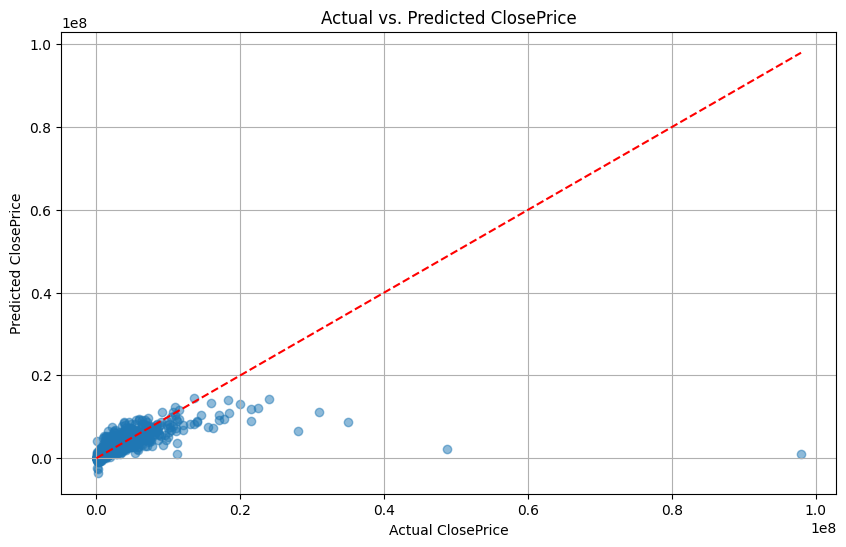

In [7]:
# Plotting actual vs. predicted values for model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual ClosePrice")
plt.ylabel("Predicted ClosePrice")
plt.title("Actual vs. Predicted ClosePrice")
plt.grid(True)
plt.show()

In [8]:
tree = DecisionTreeRegressor(max_depth=10,random_state=2026)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_r2 = r2_score(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))

print("Decision Tree R²:", tree_r2)
print("Decision Tree RMSE:", tree_rmse)

Decision Tree R²: 0.4184010884765038
Decision Tree RMSE: 1279732.8288271357


In [9]:
forest = RandomForestRegressor(n_estimators=100,random_state=2026,n_jobs=-1)

forest.fit(X_train, y_train)

forest_pred = forest.predict(X_test)

forest_r2 = r2_score(y_test, forest_pred)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_pred))

print("Random Forest R²:", forest_r2)
print("Random Forest RMSE:", forest_rmse)

Random Forest R²: 0.534479705808799
Random Forest RMSE: 1144924.4444775805


In [10]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"],
    "R2":[
        r2,
        tree_r2,
        forest_r2],
    "RMSE":[
        rmse,
        tree_rmse,
        forest_rmse]})

print(results)

               Model        R2          RMSE
0  Linear Regression  0.479669  1.210452e+06
1      Decision Tree  0.418401  1.279733e+06
2      Random Forest  0.534480  1.144924e+06
